In [1]:
# Create folder for Task 4
import os
os.makedirs('CodeAlpha_DiseasePrediction', exist_ok=True)
print("Created project folder for disease prediction")

Created project folder for disease prediction


In [2]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

In [3]:
# Load the breast cancer dataset from scikit-learn
cancer_data = load_breast_cancer()

# Create DataFrame with features
df = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)

# Add target column (0 = malignant, 1 = benign)
df['target'] = cancer_data.target

print(f"Dataset shape: {df.shape}")
print(f"Features: {cancer_data.feature_names.tolist()}")
print(f"\nTarget distribution:")
print(df['target'].value_counts())
print("0 = Malignant (cancerous), 1 = Benign (not cancerous)")

Dataset shape: (569, 31)
Features: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']

Target distribution:
target
1    357
0    212
Name: count, dtype: int64
0 = Malignant (cancerous), 1 = Benign (not cancerous)


First 5 rows of data:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst 

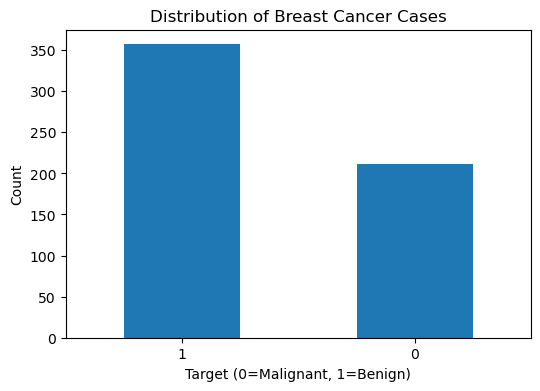

In [4]:
# Look at first few rows
print("First 5 rows of data:")
print(df.head())

# Check for missing values
print(f"\nMissing values: {df.isnull().sum().sum()}")

# Basic statistics
print("\nBasic statistics:")
print(df.describe())

# Visualize target distribution
plt.figure(figsize=(6, 4))
df['target'].value_counts().plot(kind='bar')
plt.title('Distribution of Breast Cancer Cases')
plt.xlabel('Target (0=Malignant, 1=Benign)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [5]:
# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (569, 30)
Target shape: (569,)


In [6]:
# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 455 samples
Testing set size: 114 samples


In [7]:
# Scale features to have mean=0 and variance=1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully")

Features scaled successfully


In [8]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Support Vector Machine': SVC(probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

# Train and evaluate each model
results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Train model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    # Store results
    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    }
    
    print(f"Accuracy: {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1-Score: {f1:.3f}")
    print(f"ROC-AUC: {roc_auc:.3f}")


Training Logistic Regression...
Accuracy: 0.982
Precision: 0.986
Recall: 0.986
F1-Score: 0.986
ROC-AUC: 0.995

Training Support Vector Machine...
Accuracy: 0.982
Precision: 0.986
Recall: 0.986
F1-Score: 0.986
ROC-AUC: 0.995

Training Random Forest...
Accuracy: 0.956
Precision: 0.959
Recall: 0.972
F1-Score: 0.966
ROC-AUC: 0.994



Model Performance Comparison:
                        Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression        0.982      0.986   0.986     0.986    0.995
Support Vector Machine     0.982      0.986   0.986     0.986    0.995
Random Forest              0.956      0.959   0.972     0.966    0.994

Results saved to CSV file


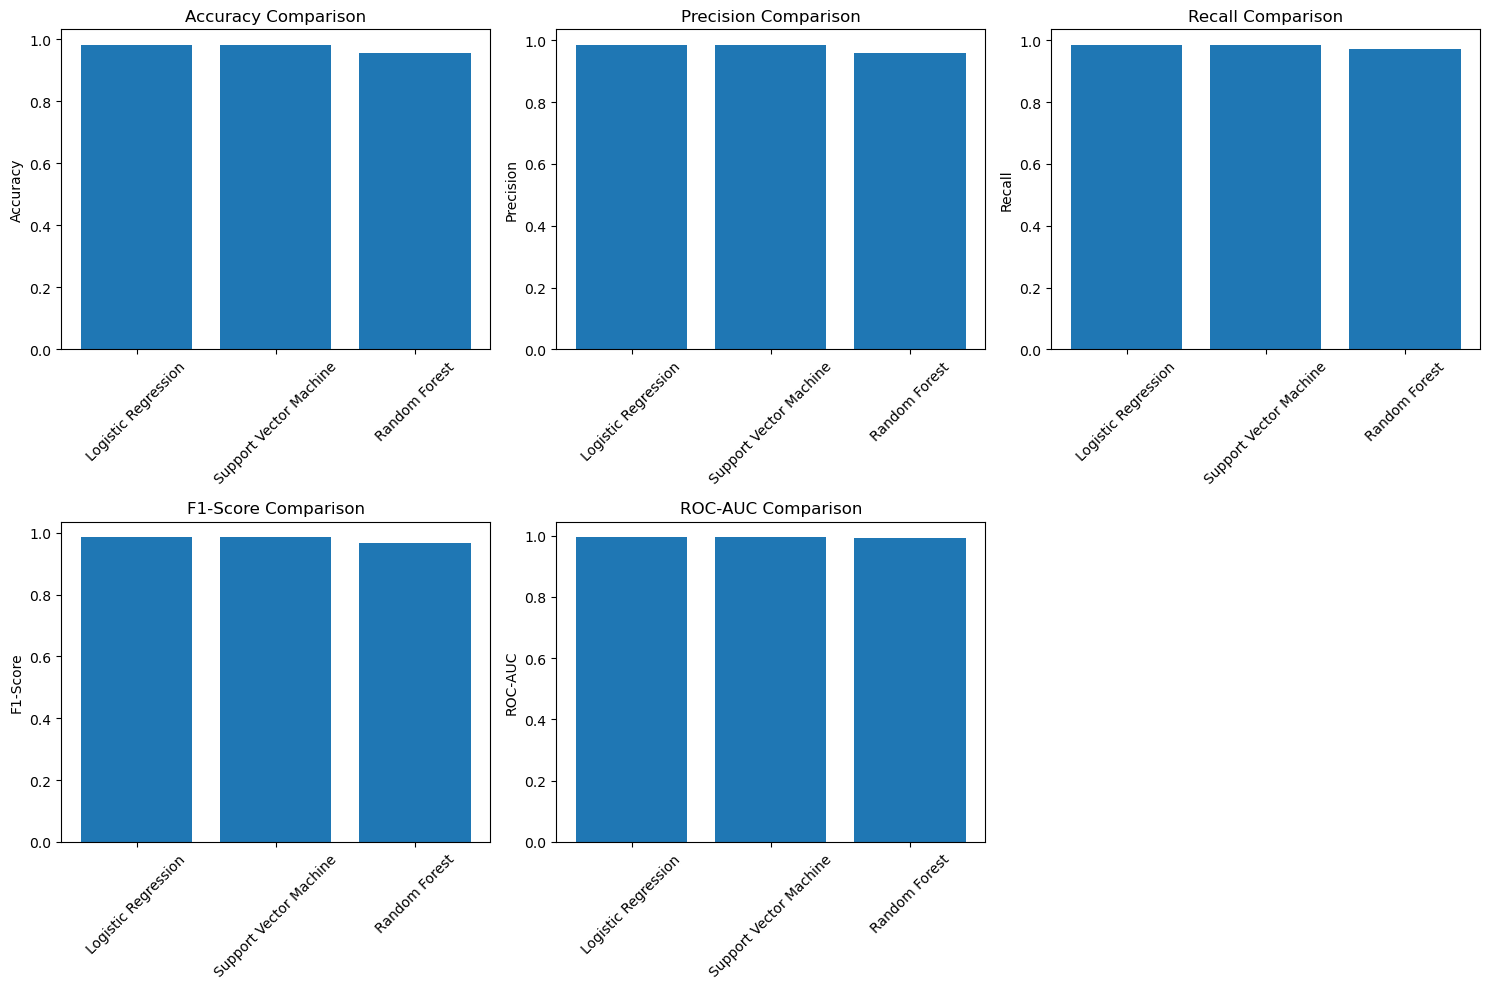

In [9]:
# Create comparison table
results_df = pd.DataFrame(results).T
print("\nModel Performance Comparison:")
print(results_df.round(3))

# Save results to CSV
results_df.to_csv('CodeAlpha_DiseasePrediction/model_comparison.csv')
print("\nResults saved to CSV file")

# Visualize comparison
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
for i, metric in enumerate(metrics):
    axes[i].bar(results_df.index, results_df[metric])
    axes[i].set_title(f'{metric} Comparison')
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=45)

axes[5].set_visible(False)
plt.tight_layout()
plt.savefig('CodeAlpha_DiseasePrediction/model_comparison.png')
plt.show()

In [10]:
# Find best model based on F1-Score
best_model_name = results_df['F1-Score'].idxmax()
best_score = results_df.loc[best_model_name, 'F1-Score']

print(f"\nBest model: {best_model_name}")
print(f"Best F1-Score: {best_score:.3f}")


Best model: Logistic Regression
Best F1-Score: 0.986


In [11]:
import joblib

# Train best model on all data
best_model = models[best_model_name]
best_model.fit(X_train_scaled, y_train)

# Save model and scaler
joblib.dump(best_model, 'CodeAlpha_DiseasePrediction/best_model.pkl')
joblib.dump(scaler, 'CodeAlpha_DiseasePrediction/scaler.pkl')

print("Model and scaler saved successfully")

Model and scaler saved successfully


In [12]:
# Function to predict for new patient
def predict_cancer(features):
    """
    Predict if tumor is malignant or benign
    features: array of 30 values (mean radius, texture, etc.)
    """
    # Scale features
    features_scaled = scaler.transform([features])
    
    # Predict
    prediction = best_model.predict(features_scaled)[0]
    probability = best_model.predict_proba(features_scaled)[0]
    
    if prediction == 1:
        result = "Benign (not cancerous)"
    else:
        result = "Malignant (cancerous)"
    
    print(f"Prediction: {result}")
    print(f"Confidence: {probability[prediction]:.2%}")
    
    return prediction, probability

# Example: Test with first patient from test set
print("Testing with a sample patient:")
predict_cancer(X_test.iloc[0].values)

Testing with a sample patient:
Prediction: Malignant (cancerous)
Confidence: 100.00%


C:\Users\Scripture\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


(np.int64(0), array([9.99999941e-01, 5.88824186e-08]))